In [1]:
import numpy as np
import pywt
from scipy.io import loadmat as load
import matplotlib.pyplot as plt

In [2]:
def compute_cwt(signal, wavelet = 'morl', scales=np.arange(1, 200)):
    coef, _ = pywt.cwt(signal, scales, wavelet)
    power = np.abs(coef)
    return power  # shape: [scale, time]

In [3]:
data = load('/home/desktop/Desktop/22104412_Docs/MiceEpilepsy/BSBEData/Data_clean_5s.mat')
X_train = data['data_4']
y_train = data['labels']
print(X_train.shape,y_train.shape)

(463, 4, 7500) (463, 7500)


In [4]:
B1 = X_train[:, 0, :]
B2 = X_train[:, 1, :]
B3 = X_train[:, 2, :]
B4 = X_train[:, 3, :]
B1.shape, B2.shape, B3.shape, B4.shape

((463, 7500), (463, 7500), (463, 7500), (463, 7500))

In [5]:
cwt1 = []
cwt2 = []
cwt3 = []
cwt4 = []
for i in range(B1.shape[0]):
    cwt1.append(compute_cwt(B1[i, :]))
    cwt2.append(compute_cwt(B2[i, :]))
    cwt3.append(compute_cwt(B3[i, :]))
    cwt4.append(compute_cwt(B4[i, :]))

cwt1 = np.array(cwt1)[:,np.newaxis,:,:]
cwt2 = np.array(cwt2)[:,np.newaxis,:,:]
cwt3 = np.array(cwt3)[:,np.newaxis,:,:]
cwt4 = np.array(cwt4)[:,np.newaxis,:,:]

In [6]:
cwt1.shape, cwt2.shape, cwt3.shape, cwt4.shape

((463, 1, 199, 7500),
 (463, 1, 199, 7500),
 (463, 1, 199, 7500),
 (463, 1, 199, 7500))

In [7]:
def normalize(img):
    return (img - np.min(img)) / (np.max(img) - np.min(img))

for i in range(cwt1.shape[0]):
    cwt1[i] = normalize(cwt1[i])
    cwt2[i] = normalize(cwt2[i])
    cwt3[i] = normalize(cwt3[i])
    cwt4[i] = normalize(cwt4[i])

In [8]:
import numpy as np
labels = y_train
# Assume `data` is your (463, 7500) array
only_0_indices = []
only_1_indices = []
both_0_1_indices = []

for i in range(labels.shape[0]):
    unique_values = np.unique(labels[i])
    if np.array_equal(unique_values, [0]):
        only_0_indices.append(i)
    elif np.array_equal(unique_values, [1]):
        only_1_indices.append(i)
    elif np.array_equal(unique_values, [0, 1]) or len(unique_values) == 2:
        both_0_1_indices.append(i)

len(only_0_indices), len(only_1_indices), len(both_0_1_indices)

(331, 18, 103)

In [9]:
sampled_0 = np.random.choice(only_0_indices, 10, replace=False)
sampled_1 = np.random.choice(only_1_indices, 10, replace=False)

In [10]:
sampled_indices = np.concatenate([sampled_0, sampled_1])
sampled_labels = y_train[sampled_indices]


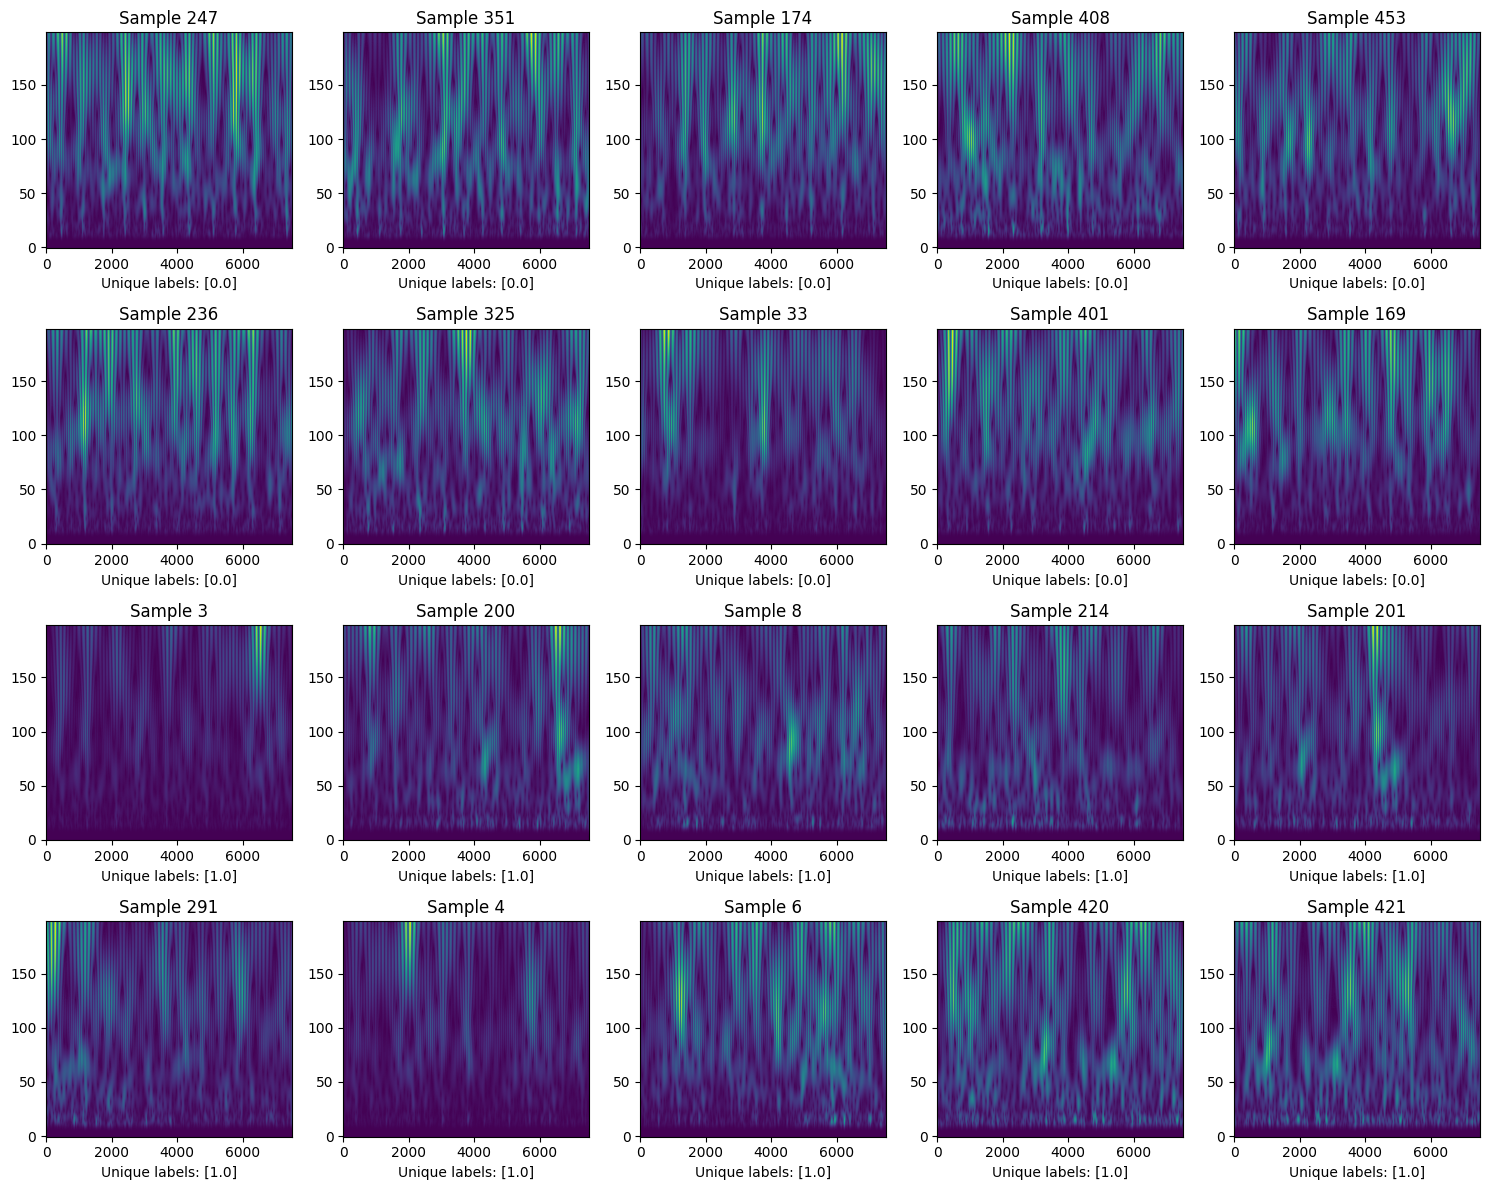

In [11]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 5, figsize=(15, 12))  # 2 rows, 5 columns

for i, idx in enumerate(sampled_indices):
    row = i // 5
    col = i % 5

    img = cwt4[idx,0]
    label_seq = labels[idx]

    axes[row, col].imshow(img, aspect='auto', origin='lower')
    unique_vals = np.unique(label_seq)
    axes[row, col].set_title(f"Sample {idx}")
    axes[row, col].set_xlabel(f"Unique labels: {unique_vals.tolist()}")

plt.tight_layout()
plt.show()


In [12]:
for i in both_0_1_indices:
    percentage_1 = np.sum(labels[i] == 1) / len(labels[i]) * 100
    if percentage_1 >= 70:
        only_1_indices.append(i)
        print('Added!')
    else:
        print(percentage_1)

59.38666666666666
59.38666666666666
Added!
56.57333333333333
26.57333333333333
15.120000000000001
46.10666666666667
6.6000000000000005
36.6
66.60000000000001
Added!
Added!
30.093333333333334
60.0
33.986666666666665
29.133333333333333
Added!
Added!
25.6
Added!
Added!
49.24
15.546666666666667
45.54666666666667
Added!
43.36
13.36
6.506666666666666
66.50666666666667
46.21333333333333
16.21333333333333
20.0
4.946666666666666
34.946666666666665
64.94666666666666
Added!
Added!
65.29333333333334
35.29333333333333
5.293333333333333
43.18666666666667
Added!
Added!
23.37333333333333
9.746666666666666
Added!
Added!
44.85333333333333
45.48
Added!
68.65333333333334
38.653333333333336
8.653333333333334
1.1466666666666667
31.14666666666667
61.14666666666667
Added!
Added!
60.08
30.080000000000002
4.786666666666667
34.78666666666667
64.78666666666668
66.67999999999999
24.346666666666668
54.346666666666664
Added!
Added!
16.186666666666667
22.439999999999998
52.44
18.56
0.0
0.0
0.0
0.0
21.226666666666667


In [13]:
len(only_1_indices), len(only_0_indices), len(both_0_1_indices)

(41, 331, 103)

In [14]:
import torch.nn.functional as F
import torch

cwt1_resized = F.interpolate(torch.tensor(cwt1), size=(199, 500), mode='bilinear', align_corners=False).numpy()
cwt2_resized = F.interpolate(torch.tensor(cwt2), size=(199, 500), mode='bilinear', align_corners=False).numpy()
cwt3_resized = F.interpolate(torch.tensor(cwt3), size=(199, 500), mode='bilinear', align_corners=False).numpy()
cwt4_resized = F.interpolate(torch.tensor(cwt4), size=(199, 500), mode='bilinear', align_corners=False).numpy()

In [15]:
cwt1_resized.shape, cwt2_resized.shape, cwt3_resized.shape, cwt4_resized.shape

((463, 1, 199, 500),
 (463, 1, 199, 500),
 (463, 1, 199, 500),
 (463, 1, 199, 500))

In [16]:
cwt = np.concatenate([cwt1_resized, cwt2_resized, cwt3_resized, cwt4_resized], axis=1)
cwt.shape

(463, 4, 199, 500)

In [17]:
indxs = np.concatenate([np.array(only_0_indices), np.array(only_1_indices)])
cwt = cwt[indxs]
y0 = np.zeros(len(only_0_indices))
y1 = np.ones(len(only_1_indices))   
y = np.concatenate([y0, y1])
print(cwt.shape, y.shape)

(372, 4, 199, 500) (372,)


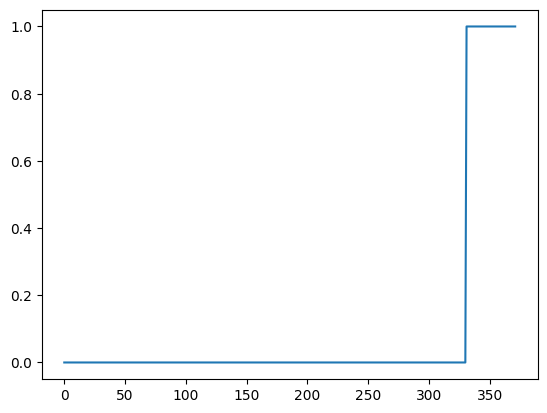

In [18]:
plt.plot(y)

In [40]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class EEGPreprocessor(nn.Module):
    def __init__(self, input_channels=4, output_channels=1):
        super(EEGPreprocessor, self).__init__()
        self.conv1x1 = nn.Conv2d(in_channels=input_channels, out_channels=output_channels, kernel_size=1)
        self.resize = nn.AdaptiveAvgPool2d((128, 128))  # Resize to AST input
        self.bn = nn.BatchNorm2d(output_channels)

    def forward(self, x):
        x = self.conv1x1(x)   # [B, 4, F, T] → [B, 3, F, T]
        x = self.resize(x)    # → [B, 3, 128, 128]
        x = self.bn(x)
        return x

In [41]:
from models.ast_models import ASTModel  # Load from AST GitHub
# You may need to pip install or clone from https://github.com/YuanGongND/ast

class ASTEEGClassifier(nn.Module):
    def __init__(self, num_classes):
        super(ASTEEGClassifier, self).__init__()
        self.eeg_pre = EEGPreprocessor()
        
        # Initialize AST pretrained on AudioSet
        self.ast = ASTModel(
            label_dim=num_classes,
            fstride=10,
            tstride=10,
            input_fdim=128,
            input_tdim=128,
            imagenet_pretrain=True,
            audioset_pretrain=False,
            model_size='base384'
        )
        
    def forward(self, x):
        x = self.eeg_pre(x)
        x = x.squeeze(1)
        out = self.ast(x)
        return out

In [49]:
model.ast.mlp_head[1]

Linear(in_features=768, out_features=2, bias=True)

In [43]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = nn.CrossEntropyLoss(reduction='none')(inputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * ((1 - pt) ** self.gamma) * ce_loss
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

In [53]:
import torch
from torch.utils.data import DataLoader, TensorDataset, Subset
from torch.optim import Adam
from torch.nn import CrossEntropyLoss
from sklearn.model_selection import StratifiedKFold
import numpy as np
from tqdm import tqdm
from sklearn.metrics import precision_score, f1_score

eeg_spectrograms = torch.tensor(cwt, dtype=torch.float32)
labels = torch.tensor(y, dtype=torch.int64)

# 5-fold stratified split
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
results = {}
for fold, (train_idx, val_idx) in enumerate(skf.split(eeg_spectrograms, labels)):
    print(f"\n Fold {fold + 1}")

    # Create subset datasets
    train_ds = Subset(TensorDataset(eeg_spectrograms, labels), train_idx)
    val_ds = Subset(TensorDataset(eeg_spectrograms, labels), val_idx)

    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=16, shuffle=True)

    # Initialize model
    model = ASTEEGClassifier(num_classes=2).to(device)

    # Freeze AST backbone
    for param in model.ast.parameters():
        param.requires_grad = False
    
    for param in model.ast.mlp_head.parameters():
        param.requires_grad = True
    
    # for name, param in model.named_parameters():
    #     print(f"{name}: {'trainable' if param.requires_grad else 'frozen'}")


    optimizer = Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
    criterion = FocalLoss()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    tL = []
    vL = []
    tAV = []
    vAV = []
    f1 =[]
    prec = []
    epochs = 50
    for epoch in range(epochs):
        trainAccuracy = 0
        totalLoss = 0
        traincorrect = 0
        traintotal = 0
        all_preds = []
        all_labels = []
        with tqdm(train_loader, unit='batch') as tepoch:
            model.train()
            for imagest,lab in tepoch:
                imagest = imagest.to(device)
                lab = lab.to(device)
                optimizer.zero_grad()
                outputs = (model(imagest))
                _,predindex = torch.max(outputs, dim = 1)
                loss = criterion(outputs,lab)
                loss.backward()
                optimizer.step()
                totalLoss+=loss.item()
                acc = (predindex==lab).sum().item()
                traincorrect += acc
                traintotal += lab.shape[0]
                trainAccuracy = traincorrect/traintotal
                tepoch.set_postfix(loss=loss.item(),totalLoss =totalLoss/len(train_loader), TrainAccuracy= 100.*trainAccuracy)      
            model.eval()
            with torch.no_grad():
                with tqdm(val_loader, unit='batch') as tepoch:
                    total = 0
                    valAccuracy = 0
                    valcorrect = 0
                    valtotal = 0
                    val_loss = 0
                    for imagesv,labv in tepoch:
                        imagesv = imagesv.to(device)
                        labelsv = labv.to(device)
                        outval = (model(imagesv))
                        _,predindexval = torch.max(outval,dim = 1)

                        all_preds.extend(predindexval.cpu().numpy())
                        all_labels.extend(labelsv.cpu().numpy())

                        acc = (predindexval == labelsv).sum().item()
                        valcorrect +=acc
                        valtotal +=labelsv.shape[0]
                        valAccuracy = valcorrect/valtotal
                        lossv = criterion(outval,labelsv)
                        val_loss+= lossv.item()
                        tepoch.set_postfix(lossv=lossv.item(),valLoss =val_loss/len(val_loader), ValAccuracy= 100.*valAccuracy)
        print('Epoch [{}], Loss_t: {:.4f},Loss_v: {:.4f}, train_acc:{:.4f}, val_acc:{:.4f}'.format(epoch, totalLoss/len(train_loader), val_loss/len(val_loader),
                                                                                                    100.*trainAccuracy,100.*valAccuracy))
        tL.append(totalLoss/len(train_loader))
        vL.append(val_loss/len(val_loader))
        tAV.append(100.*trainAccuracy)
        vAV.append( 100.*valAccuracy)
        prec.append(precision_score(all_labels, all_preds, average='binary', zero_division=0))
        f1.append(f1_score(all_labels, all_preds, average='binary', zero_division=0))
    results[str(fold)] = {'trainLoss': tL, 'valLoss': vL,
                            'trainAccuracy': tAV, 'valAccuracy': vAV,
                            'precision': prec, 'f1': f1}



 Fold 1
---------------AST Model Summary---------------
ImageNet pretraining: True, AudioSet pretraining: False
frequncey stride=10, time stride=10
number of patches=144


100%|██████████| 3/3 [00:00<00:00, 25.86batch/s, ValAccuracy=86.8, lossv=0.114, valLoss=0.119]


Epoch [0], Loss_t: 0.0975,Loss_v: 0.1188, train_acc:86.8263, val_acc:86.8421


100%|██████████| 3/3 [00:00<00:00, 22.57batch/s, ValAccuracy=89.5, lossv=0.11, valLoss=0.0966]  


Epoch [1], Loss_t: 0.0541,Loss_v: 0.0966, train_acc:93.1138, val_acc:89.4737


...

Epoch [47], Loss_t: 0.0054,Loss_v: 0.0453, train_acc:99.7015, val_acc:94.5946


100%|██████████| 3/3 [00:00<00:00, 27.09batch/s, ValAccuracy=94.6, lossv=0.027, valLoss=0.032]


Epoch [48], Loss_t: 0.0044,Loss_v: 0.0320, train_acc:100.0000, val_acc:94.5946


100%|██████████| 3/3 [00:00<00:00, 26.85batch/s, ValAccuracy=94.6, lossv=0.0161, valLoss=0.0325]

Epoch [49], Loss_t: 0.0037,Loss_v: 0.0325, train_acc:100.0000, val_acc:94.5946


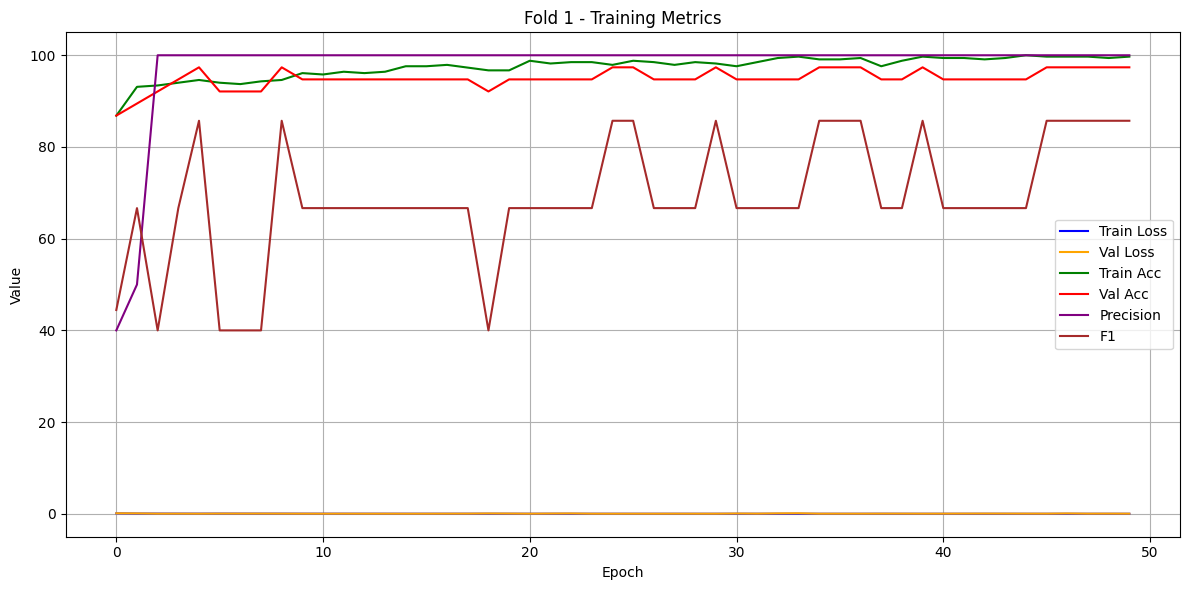

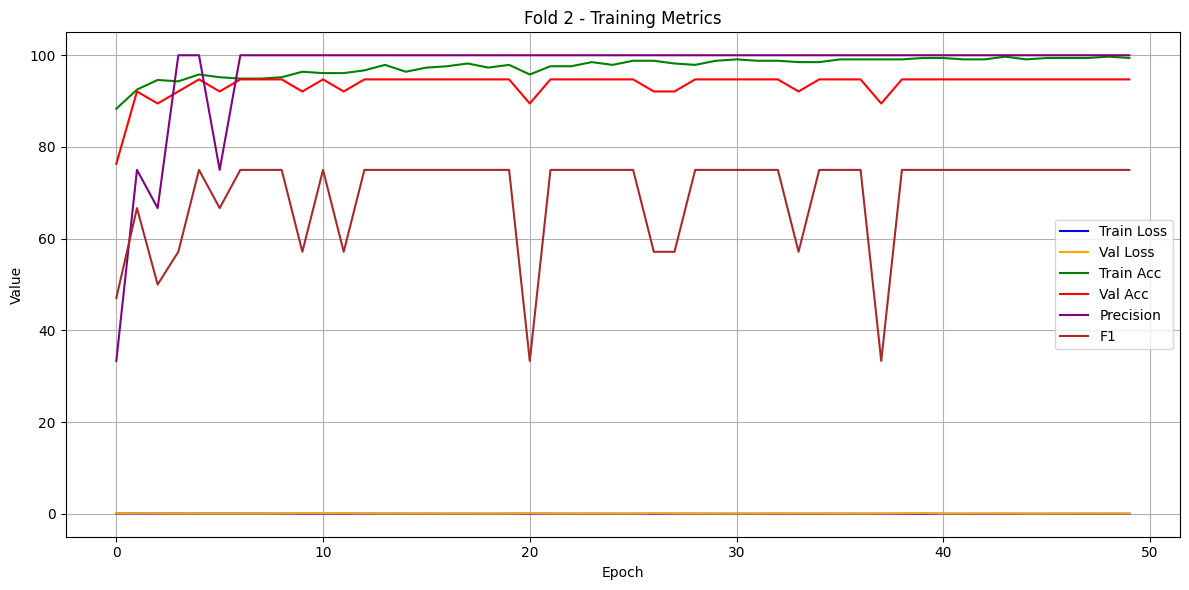

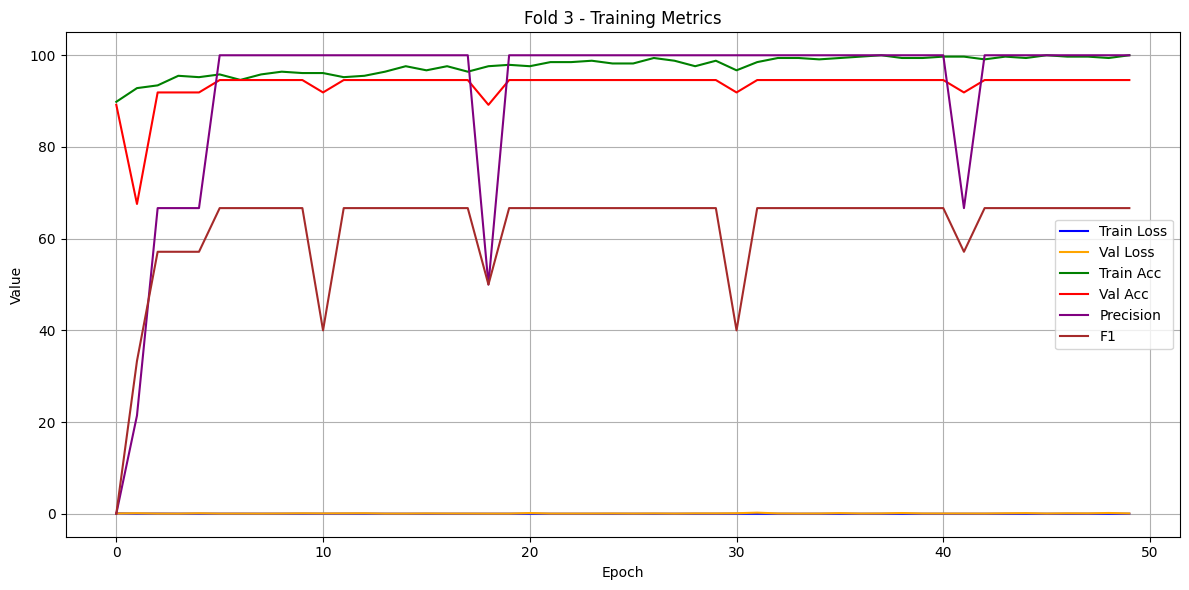

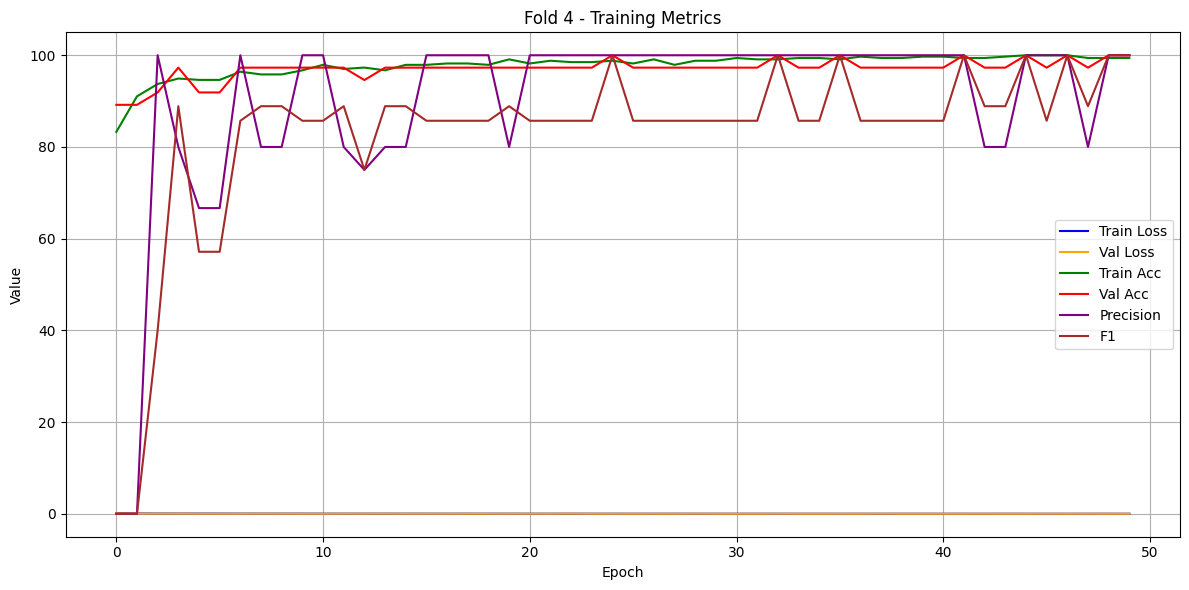

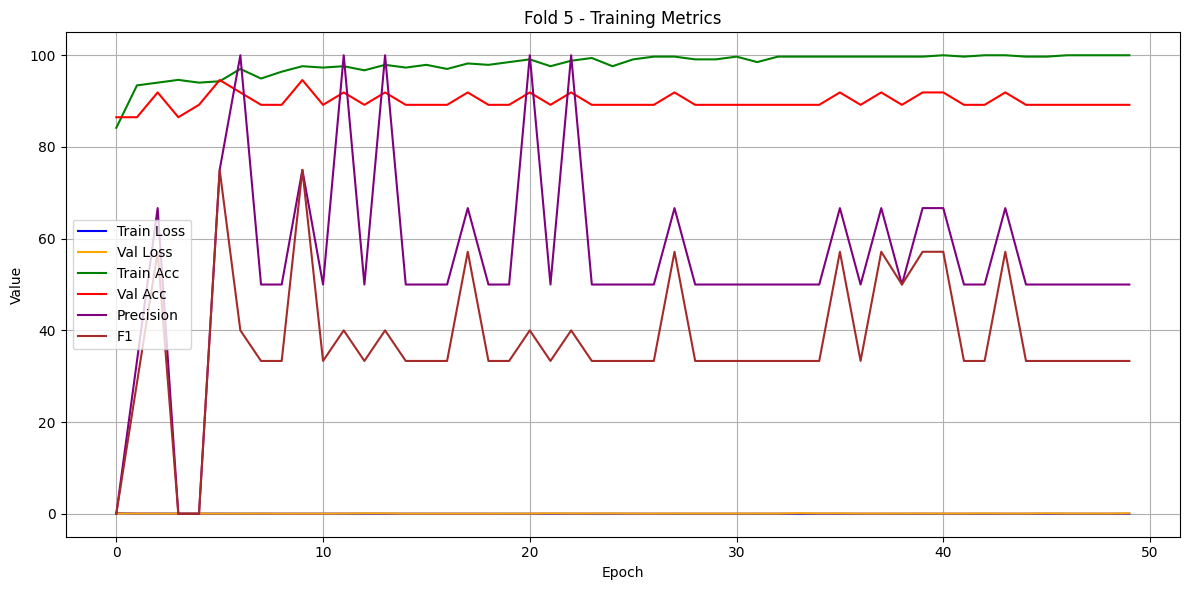

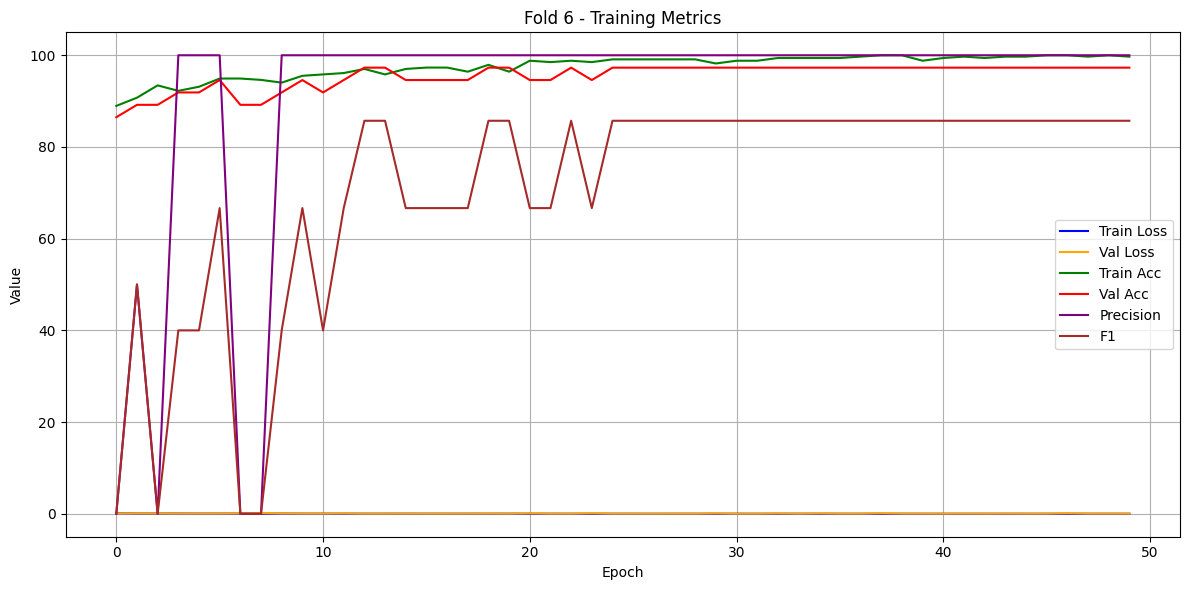

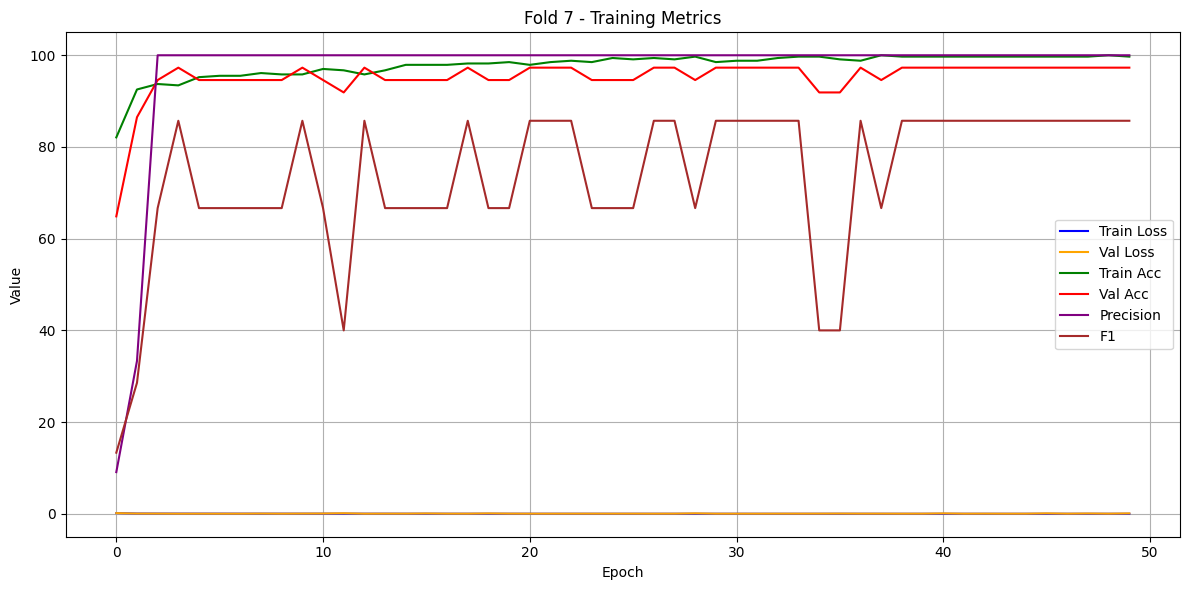

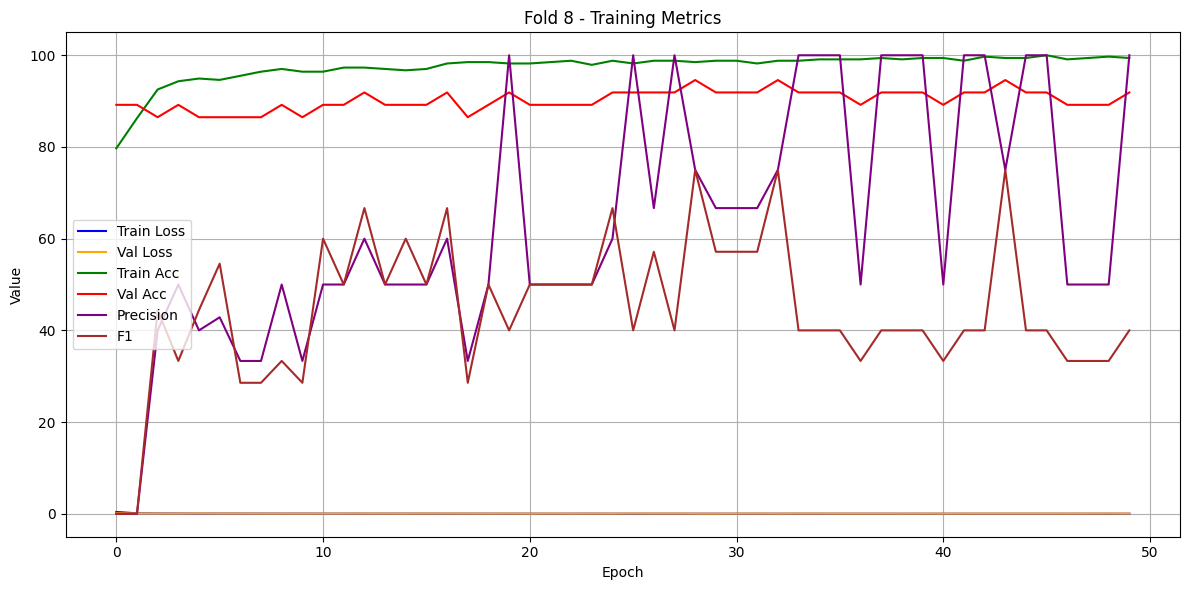

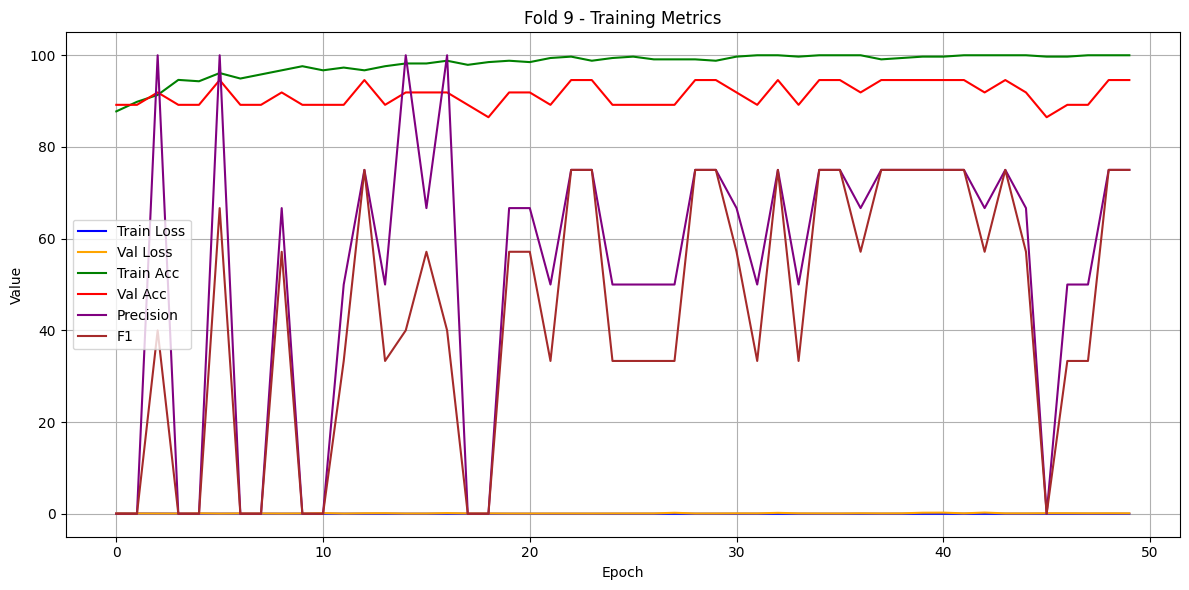

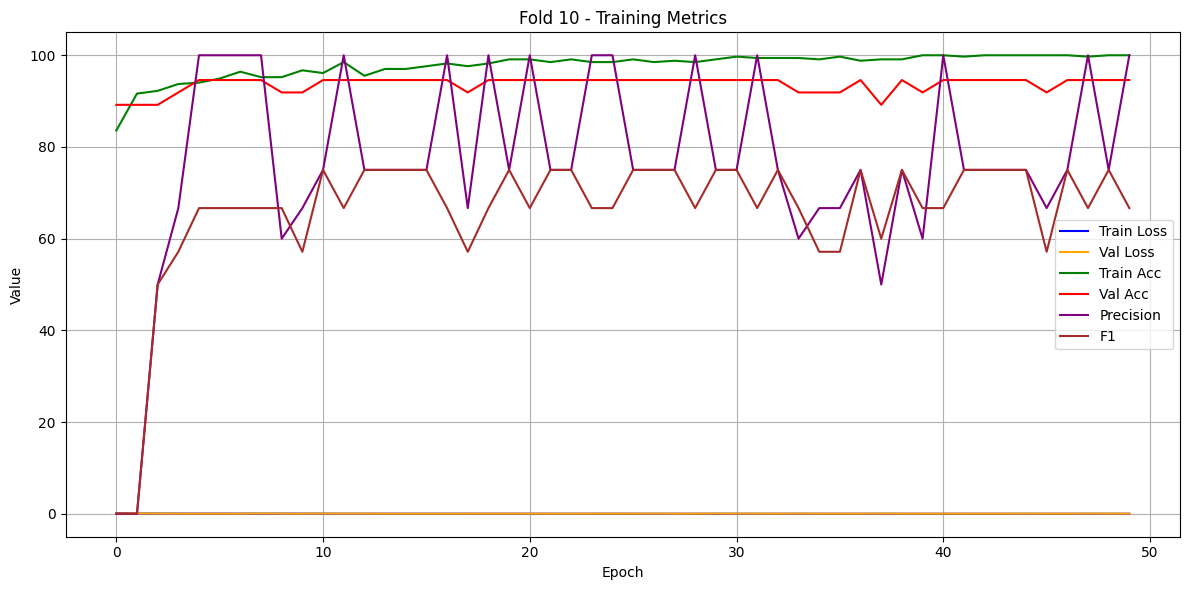

In [54]:
import matplotlib.pyplot as plt

metrics = ['trainLoss', 'valLoss', 'trainAccuracy', 'valAccuracy', 'precision', 'f1']
colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']
labels = ['Train Loss', 'Val Loss', 'Train Acc', 'Val Acc', 'Precision', 'F1']

for fold in results:
    plt.figure(figsize=(12, 6))
    for metric, color, label in zip(metrics, colors, labels):
        values = results[fold][metric]
        # Multiply precision and f1 by 100
        if metric in ['precision', 'f1']:
            values = [v * 100 for v in values]
        plt.plot(values, label=label, color=color)
    plt.title(f"Fold {int(fold)+1} - Training Metrics")
    plt.xlabel("Epoch")
    plt.ylabel("Value")
    plt.legend(loc="best")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [55]:
best_f1_scores = []
best_precision_scores = []

for fold in results:
    best_f1 = max(results[fold]['f1'])
    best_prec = max(results[fold]['precision'])
    best_f1_scores.append(best_f1)
    best_precision_scores.append(best_prec)
    print(f"Fold {int(fold)+1}: Best F1 = {best_f1*100:.2f}%, Best Precision = {best_prec*100:.2f}%")

# Compute average of bests
mean_best_f1 = sum(best_f1_scores) / len(best_f1_scores)
mean_best_precision = sum(best_precision_scores) / len(best_precision_scores)

print("\nMean of Best Scores Across 5 Folds:")
print(f"Mean Best F1 Score: {mean_best_f1*100:.2f}%")
print(f"Mean Best Precision Score: {mean_best_precision*100:.2f}%")

Fold 1: Best F1 = 85.71%, Best Precision = 100.00%
Fold 2: Best F1 = 75.00%, Best Precision = 100.00%
Fold 3: Best F1 = 66.67%, Best Precision = 100.00%
Fold 4: Best F1 = 100.00%, Best Precision = 100.00%
Fold 5: Best F1 = 75.00%, Best Precision = 100.00%
Fold 6: Best F1 = 85.71%, Best Precision = 100.00%
Fold 7: Best F1 = 85.71%, Best Precision = 100.00%
Fold 8: Best F1 = 75.00%, Best Precision = 100.00%
Fold 9: Best F1 = 75.00%, Best Precision = 100.00%
Fold 10: Best F1 = 75.00%, Best Precision = 100.00%

Mean of Best Scores Across 5 Folds:
Mean Best F1 Score: 79.88%
Mean Best Precision Score: 100.00%
